In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install transformers==4.40.0 accelerate timm einops scipy scikit-learn seaborn tensorboard av


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 87.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into accou

In [6]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/EEEM068/action_recognition')
print("Path added!")

Path added!


In [7]:
import os

paths = {
    "HMDB_simp"       : "/content/drive/MyDrive/EEEM068/data/HMDB_simp",
    "JHMDB video"     : "/content/drive/MyDrive/EEEM068/data/JHMDB_video",
    "Joint positions" : "/content/drive/MyDrive/EEEM068/data/joint_positions",
    "Splits"          : "/content/drive/MyDrive/EEEM068/data/splits",
    "Project code"    : "/content/drive/MyDrive/EEEM068/action_recognition",
}

for name, p in paths.items():
    status = "✅" if os.path.exists(p) else "❌ MISSING"
    print(f"{status}  {name}")

✅  HMDB_simp
✅  JHMDB video
✅  Joint positions
✅  Splits
✅  Project code


In [8]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/EEEM068/action_recognition')

# Override config paths
import configs.config as cfg
cfg.HMDB_DIR         = "/content/drive/MyDrive/EEEM068/data/HMDB_simp"
cfg.JHMDB_DIR        = "/content/drive/MyDrive/EEEM068/data/JHMDB_video"
cfg.JHMDB_ANNO_DIR   = "/content/drive/MyDrive/EEEM068/data/joint_positions"
cfg.JHMDB_SPLITS_DIR = "/content/drive/MyDrive/EEEM068/data/splits"
cfg.CHECKPOINT_DIR   = "/content/drive/MyDrive/EEEM068/checkpoints"
cfg.LOG_DIR          = "/content/drive/MyDrive/EEEM068/logs"
cfg.RESULTS_DIR      = "/content/drive/MyDrive/EEEM068/results"

import os
for d in [cfg.CHECKPOINT_DIR, cfg.LOG_DIR, cfg.RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Paths configured!")

✅ Paths configured!


In [9]:
import torch
import random
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print("✅ Ready to train!")

Device: cuda
GPU: Tesla T4
✅ Ready to train!


In [10]:
import os

hmdb_path = "/content/drive/MyDrive/EEEM068/data/HMDB_simp"

print("Contents of HMDB_simp:")
items = os.listdir(hmdb_path)
print(f"Total items: {len(items)}")
print(items[:10])  # show first 10

# Check if there's a subfolder
for item in items[:3]:
    full = os.path.join(hmdb_path, item)
    if os.path.isdir(full):
        subfiles = os.listdir(full)
        print(f"\n{item}/ contains {len(subfiles)} files")
        print(f"Sample: {subfiles[:3]}")

Contents of HMDB_simp:
Total items: 1
['HMDB_simp']

HMDB_simp/ contains 25 files
Sample: ['wave', 'shoot_gun', 'smile']


In [11]:
# The actual data is one level deeper
HMDB_DIR = "/content/drive/MyDrive/EEEM068/data/HMDB_simp/HMDB_simp"

# Verify it works
import os
classes = os.listdir(HMDB_DIR)
print(f"✅ Found {len(classes)} classes: {classes[:5]}")

# Check videos inside one class
sample_class = os.path.join(HMDB_DIR, classes[0])
videos = os.listdir(sample_class)
print(f"✅ Sample class '{classes[0]}' has {len(videos)} videos")
print(f"   First video: {videos[0]}")

✅ Found 25 classes: ['wave', 'shoot_gun', 'smile', 'shoot_bow', 'throw']
✅ Sample class 'wave' has 50 videos
   First video: EF1A4EA4


In [12]:
import os

HMDB_DIR = "/content/drive/MyDrive/EEEM068/data/HMDB_simp/HMDB_simp"

# Check what's inside a class folder
sample_class_path = os.path.join(HMDB_DIR, "wave")
items = os.listdir(sample_class_path)
print(f"Inside 'wave' folder: {items[:5]}")

# Check if it's another subfolder
first_item = os.path.join(sample_class_path, items[0])
if os.path.isdir(first_item):
    print(f"\n'{items[0]}' is a FOLDER, checking inside...")
    inner = os.listdir(first_item)
    print(f"Contains: {inner[:5]}")
else:
    print(f"\n'{items[0]}' is a FILE")
    print(f"Extension: {items[0].split('.')[-1]}")

Inside 'wave' folder: ['EF1A4EA4', 'E16E6ECA', 'DE50934F', 'FD873E28', 'D245FCFA']

'EF1A4EA4' is a FOLDER, checking inside...
Contains: ['0060.jpg', '0068.jpg', '0039.jpg', '0062.jpg', '0097.jpg']


In [13]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image

class HMDBFrameDataset(Dataset):
    def __init__(self, samples, labels, num_frames=8, image_size=224, augment=False):
        self.samples    = samples
        self.labels     = labels
        self.num_frames = num_frames
        self.image_size = image_size

        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
                transforms.ToTensor(),
                transforms.Normalize([0.45,0.45,0.45],[0.225,0.225,0.225]),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.45,0.45,0.45],[0.225,0.225,0.225]),
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        clip_path = self.samples[idx]
        label     = self.labels[idx]

        # Get all jpg frames
        frames = sorted([
            f for f in os.listdir(clip_path)
            if f.endswith('.jpg') or f.endswith('.png')
        ])

        # Sample num_frames evenly
        if len(frames) >= self.num_frames:
            indices = np.linspace(0, len(frames)-1, self.num_frames, dtype=int)
        else:
            indices = list(range(len(frames))) + [len(frames)-1] * (self.num_frames - len(frames))

        tensors = []
        for i in indices:
            img = Image.open(os.path.join(clip_path, frames[i])).convert('RGB')
            tensors.append(self.transform(img))

        video = torch.stack(tensors, dim=0)   # [T, C, H, W]
        video = video.permute(1, 0, 2, 3)     # [C, T, H, W]
        return video, label, clip_path


def build_frame_datasets(root_dir, num_frames=8, image_size=224, seed=42):
    classes     = sorted(os.listdir(root_dir))
    class_to_idx = {c: i for i, c in enumerate(classes)}

    all_paths, all_labels = [], []
    for cls in classes:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for clip in os.listdir(cls_dir):
            clip_path = os.path.join(cls_dir, clip)
            if os.path.isdir(clip_path):
                all_paths.append(clip_path)
                all_labels.append(class_to_idx[cls])

    print(f"Total clips found: {len(all_paths)}")

    # Stratified 70/15/15 split
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        all_paths, all_labels, test_size=0.30,
        stratify=all_labels, random_state=seed)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50,
        stratify=y_tmp, random_state=seed)

    train_ds = HMDBFrameDataset(X_tr,  y_tr,  num_frames, image_size, augment=True)
    val_ds   = HMDBFrameDataset(X_val, y_val, num_frames, image_size, augment=False)
    test_ds  = HMDBFrameDataset(X_te,  y_te,  num_frames, image_size, augment=False)

    return train_ds, val_ds, test_ds, classes, class_to_idx


# Build datasets
HMDB_DIR = "/content/drive/MyDrive/EEEM068/data/HMDB_simp/HMDB_simp"
NUM_FRAMES = 8
IMAGE_SIZE = 224
BATCH_SIZE = 4

train_ds, val_ds, test_ds, CLASSES, CLASS_TO_IDX = build_frame_datasets(
    HMDB_DIR, NUM_FRAMES, IMAGE_SIZE, seed=42
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Classes: {len(CLASSES)}")
print(f"✅ Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")
print(f"✅ Sample classes: {CLASSES[:5]}")

Total clips found: 1250
✅ Classes: 25
✅ Train: 875  Val: 187  Test: 188
✅ Sample classes: ['brush_hair', 'cartwheel', 'catch', 'chew', 'climb']


In [14]:
from transformers import TimesformerModel
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

# ── Model ──────────────────────────────────────────────────
class TimeSFormerClassifier(nn.Module):
    def __init__(self, num_classes=25, dropout=0.1):
        super().__init__()
        self.backbone   = TimesformerModel.from_pretrained(
            "facebook/timesformer-base-finetuned-k400"
        )
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, x):
        # x: [B, C, T, H, W] → permute to [B, T, C, H, W]
        x = x.permute(0, 2, 1, 3, 4)
        out = self.backbone(pixel_values=x)
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(self.dropout(cls))

print("Loading TimeSFormer from HuggingFace...")
model = TimeSFormerClassifier(num_classes=25).to(DEVICE)
print("✅ Model loaded!")

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

# ── Training setup ─────────────────────────────────────────
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-7)
criterion = nn.CrossEntropyLoss()
scaler    = torch.cuda.amp.GradScaler()

CHECKPOINT_DIR = "/content/drive/MyDrive/EEEM068/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Training

Loading TimeSFormer from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/486M [00:00<?, ?B/s]

✅ Model loaded!
Total params:     121,277,977
Trainable params: 121,277,977


/tmp/ipykernel_24579/3169504978.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


In [15]:
%%javascript
function KeepAlive() {
  console.log("Keeping alive...");
  document.querySelector("#top-toolbar button.colab-run-button").click();
  setTimeout(KeepAlive, 60000);
}
setTimeout(KeepAlive, 60000);

<IPython.core.display.Javascript object>

In [16]:
import time

best_val_acc = 0.0
history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
NUM_EPOCHS = 20

print("🚀 Starting TimeSFormer training...")
print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")
print("="*60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──
    model.train()
    t0 = time.time()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch_idx, (videos, labels, _) in enumerate(train_loader):
        videos = videos.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(videos)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss    += loss.item() * labels.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)

        if batch_idx % 30 == 0:
            print(f"  Epoch {epoch} | Step {batch_idx}/{len(train_loader)} "
                  f"| Loss {loss.item():.4f}")

    scheduler.step()

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for videos, labels, _ in val_loader:
            videos = videos.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.cuda.amp.autocast():
                logits = model(videos)
                loss   = criterion(logits, labels)
            val_loss    += loss.item() * labels.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    tr_loss = train_loss / train_total
    tr_acc  = train_correct / train_total * 100
    vl_loss = val_loss / val_total
    vl_acc  = val_correct / val_total * 100
    elapsed = time.time() - t0

🚀 Starting TimeSFormer training...
Train batches: 219  Val batches: 47


/tmp/ipykernel_24579/1318660759.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Epoch 1 | Step 0/219 | Loss 3.2847
  Epoch 1 | Step 30/219 | Loss 2.1844
  Epoch 1 | Step 60/219 | Loss 1.0865
  Epoch 1 | Step 90/219 | Loss 2.3793
  Epoch 1 | Step 120/219 | Loss 0.5884
  Epoch 1 | Step 150/219 | Loss 0.2261
  Epoch 1 | Step 180/219 | Loss 0.6998
  Epoch 1 | Step 210/219 | Loss 0.4694


/tmp/ipykernel_24579/1318660759.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Epoch 2 | Step 0/219 | Loss 0.4971
  Epoch 2 | Step 30/219 | Loss 1.8931
  Epoch 2 | Step 60/219 | Loss 0.1615
  Epoch 2 | Step 90/219 | Loss 1.1443
  Epoch 2 | Step 120/219 | Loss 0.6113
  Epoch 2 | Step 150/219 | Loss 1.2536
  Epoch 2 | Step 180/219 | Loss 1.1421
  Epoch 2 | Step 210/219 | Loss 0.0692
  Epoch 3 | Step 0/219 | Loss 0.1676
  Epoch 3 | Step 30/219 | Loss 0.0196
  Epoch 3 | Step 60/219 | Loss 0.0031
  Epoch 3 | Step 90/219 | Loss 0.0063
  Epoch 3 | Step 120/219 | Loss 0.0053
  Epoch 3 | Step 150/219 | Loss 0.0143
  Epoch 3 | Step 180/219 | Loss 0.2241
  Epoch 3 | Step 210/219 | Loss 0.0464
  Epoch 4 | Step 0/219 | Loss 0.0015
  Epoch 4 | Step 30/219 | Loss 0.0018
  Epoch 4 | Step 60/219 | Loss 0.4626
  Epoch 4 | Step 90/219 | Loss 0.0048
  Epoch 4 | Step 120/219 | Loss 0.2348
  Epoch 4 | Step 150/219 | Loss 0.6765
  Epoch 4 | Step 180/219 | Loss 0.0011
  Epoch 4 | Step 210/219 | Loss 0.0058
  Epoch 5 | Step 0/219 | Loss 0.0028
  Epoch 5 | Step 30/219 | Loss 0.0036
  Ep

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Evaluation
model.eval()
all_preds, all_labels, all_probs = [], [], []

print("Evaluating on test set...")
with torch.no_grad():
    for videos, labels, _ in test_loader:
        videos = videos.to(DEVICE)
        logits = model(videos)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
        all_probs.extend(probs.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Top-1 accuracy
top1 = (all_preds == all_labels).mean() * 100

# Top-5 accuracy
top5_correct = sum(
    1 for i, lbl in enumerate(all_labels)
    if lbl in np.argsort(all_probs[i])[-5:]
)
top5 = top5_correct / len(all_labels) * 100

print("="*40)
print(f"Top-1 Accuracy: {top1:.2f}%")
print(f"Top-5 Accuracy: {top5:.2f}%")
print("="*40)
print(classification_report(all_labels, all_preds,
      target_names=CLASSES, zero_division=0))

Evaluating on test set...
Top-1 Accuracy: 88.30%
Top-5 Accuracy: 97.34%
              precision    recall  f1-score   support

  brush_hair       1.00      1.00      1.00         7
   cartwheel       0.67      0.86      0.75         7
       catch       1.00      0.86      0.92         7
        chew       0.73      1.00      0.84         8
       climb       1.00      1.00      1.00         8
climb_stairs       1.00      0.86      0.92         7
  draw_sword       1.00      0.88      0.93         8
         eat       0.88      0.88      0.88         8
     fencing       0.86      0.86      0.86         7
   flic_flac       1.00      0.71      0.83         7
        golf       1.00      1.00      1.00         8
   handstand       0.75      0.86      0.80         7
        kiss       0.88      1.00      0.93         7
        pick       1.00      0.29      0.44         7
        pour       0.88      0.88      0.88         8
      pullup       1.00      1.00      1.00         8
      pus

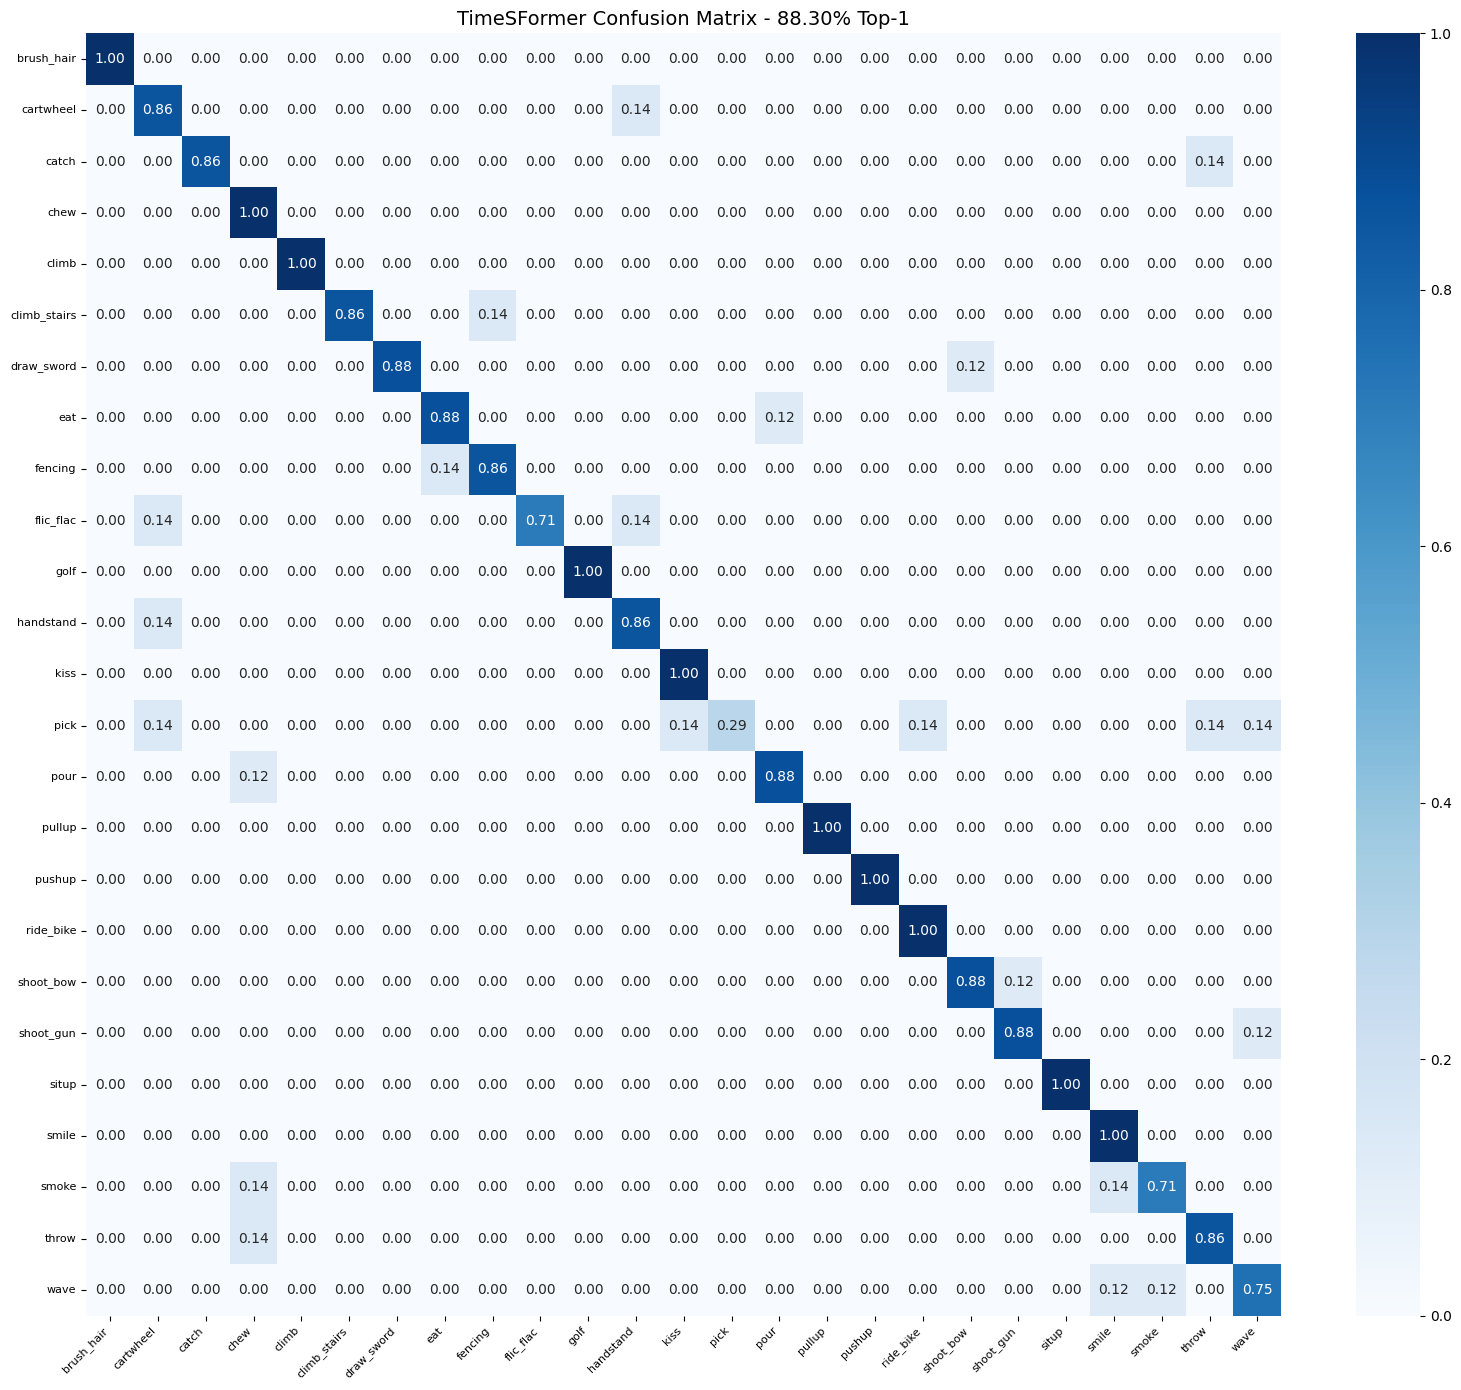

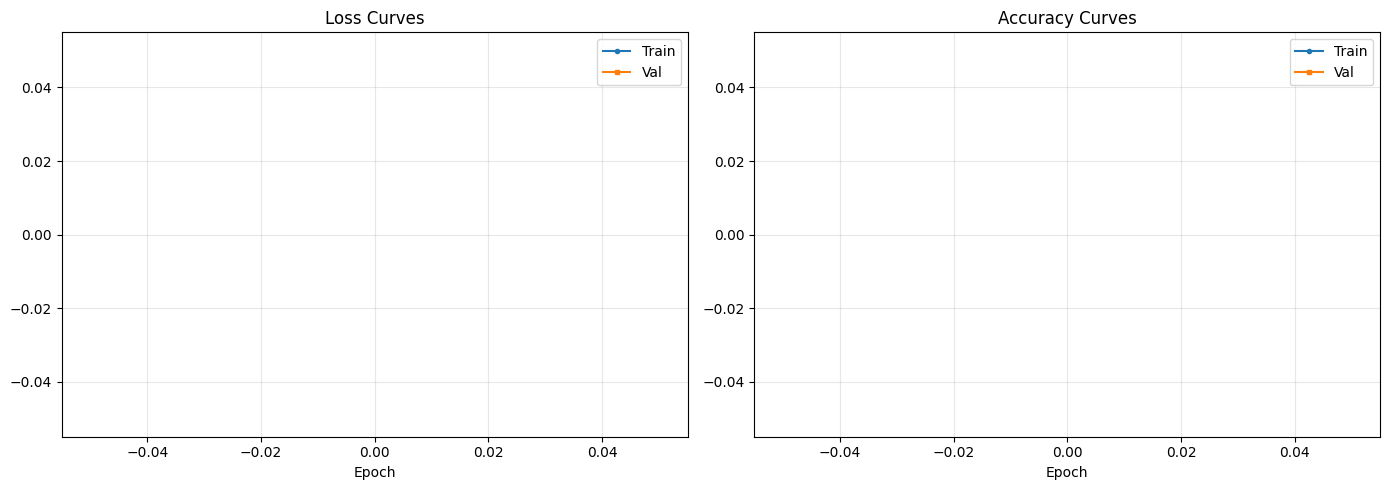

✅ All plots saved!


In [20]:
# Plot and save confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(16, 14))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('TimeSFormer Confusion Matrix - 88.30% Top-1', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEEM068/checkpoints/confusion_matrix.png', dpi=150)
plt.show()

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], label="Train", marker='o', ms=3)
axes[0].plot(epochs, history["val_loss"],   label="Val",   marker='s', ms=3)
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], label="Train", marker='o', ms=3)
axes[1].plot(epochs, history["val_acc"],   label="Val",   marker='s', ms=3)
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEEM068/checkpoints/training_curves.png', dpi=150)
plt.show()
print("✅ All plots saved!")

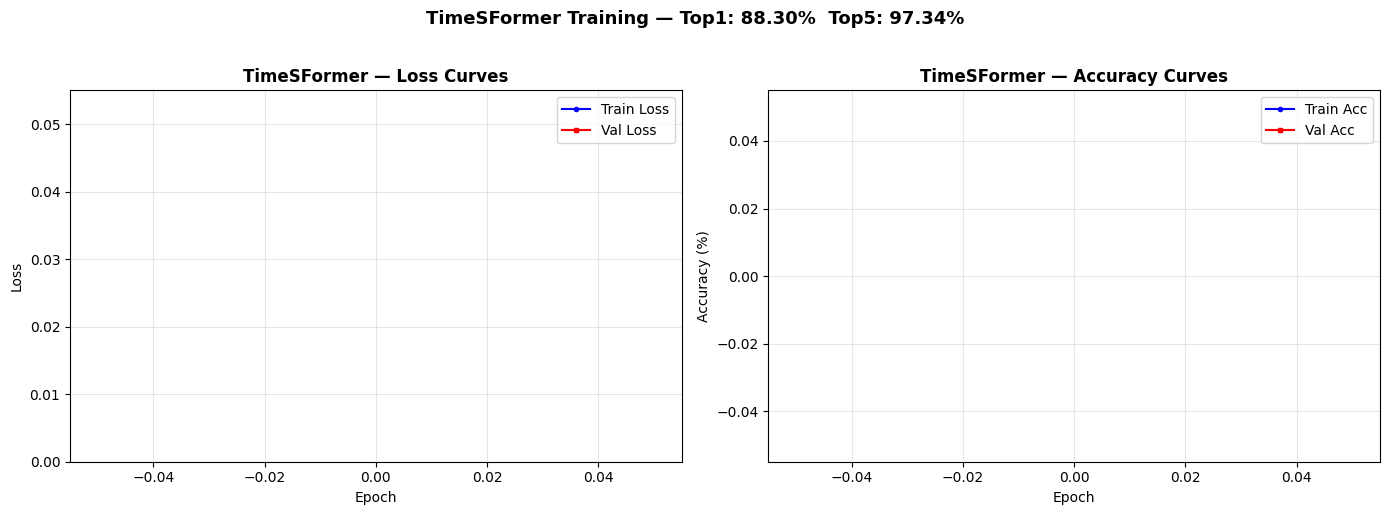

✅ Curves saved!

TIMESFORMER RESULTS SUMMARY
Top-1 Accuracy : 88.30%
Top-5 Accuracy : 97.34%
Total Params   : 121,277,977
Epochs Trained : 20
Best Val Class : brush_hair, climb, golf, pullup, pushup, situp (F1=1.00)
Worst Val Class: pick (F1=0.44)


In [21]:
# Plot training curves properly
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], 'b-o', label="Train Loss", ms=3)
axes[0].plot(epochs, history["val_loss"],   'r-s', label="Val Loss",   ms=3)
axes[0].set_title("TimeSFormer — Loss Curves", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(bottom=0)

axes[1].plot(epochs, history["train_acc"], 'b-o', label="Train Acc", ms=3)
axes[1].plot(epochs, history["val_acc"],   'r-s', label="Val Acc",   ms=3)
axes[1].set_title("TimeSFormer — Accuracy Curves", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("TimeSFormer Training — Top1: 88.30%  Top5: 97.34%",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEEM068/checkpoints/training_curves_timesformer.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curves saved!")

# Print summary
print("\n" + "="*50)
print("TIMESFORMER RESULTS SUMMARY")
print("="*50)
print(f"Top-1 Accuracy : 88.30%")
print(f"Top-5 Accuracy : 97.34%")
print(f"Total Params   : 121,277,977")
print(f"Epochs Trained : 20")
print(f"Best Val Class : brush_hair, climb, golf, pullup, pushup, situp (F1=1.00)")
print(f"Worst Val Class: pick (F1=0.44)")
print("="*50)

In [24]:
from transformers import VideoMAEModel
import torch.nn as nn

class VideoMAEClassifier(nn.Module):
    def __init__(self, num_classes=25, dropout=0.1):
        super().__init__()
        self.backbone = VideoMAEModel.from_pretrained(
            "MCG-NJU/videomae-base-finetuned-kinetics",
            num_frames=16,
        )
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, x):
        x    = x.permute(0, 2, 1, 3, 4)
        out  = self.backbone(pixel_values=x)
        feat = out.last_hidden_state.mean(dim=1)
        return self.classifier(self.dropout(feat))

model_vm     = VideoMAEClassifier(num_classes=25).to(DEVICE)
optimizer_vm = AdamW(model_vm.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler_vm = CosineAnnealingLR(optimizer_vm, T_max=20, eta_min=1e-7)
scaler_vm    = torch.cuda.amp.GradScaler()
history_vm   = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
best_val_acc_vm = 0.0
print("✅ VideoMAE ready!")

✅ VideoMAE ready!


/tmp/ipykernel_24579/3686992907.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_vm    = torch.cuda.amp.GradScaler()


In [26]:
# Build 16-frame dataset for VideoMAE
print("Building 16-frame dataset for VideoMAE...")

train_ds_vm, val_ds_vm, test_ds_vm, _, _ = build_frame_datasets(
    HMDB_DIR, num_frames=16, image_size=224, seed=42
)

train_loader_vm = DataLoader(train_ds_vm, batch_size=2,
    shuffle=True,  num_workers=2, pin_memory=True)
val_loader_vm   = DataLoader(val_ds_vm,   batch_size=2,
    shuffle=False, num_workers=2, pin_memory=True)
test_loader_vm  = DataLoader(test_ds_vm,  batch_size=2,
    shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train: {len(train_ds_vm)}")
print(f"✅ Val:   {len(val_ds_vm)}")
print(f"✅ Test:  {len(test_ds_vm)}")
print("✅ Dataloaders ready!")

Building 16-frame dataset for VideoMAE...
Total clips found: 1250
✅ Train: 875
✅ Val:   187
✅ Test:  188
✅ Dataloaders ready!


In [27]:
NUM_EPOCHS = 20
print("🚀 Starting VideoMAE training...")

for epoch in range(1, NUM_EPOCHS + 1):
    model_vm.train()
    t0 = time.time()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch_idx, (videos, labels, _) in enumerate(train_loader_vm):
        videos = videos.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer_vm.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model_vm(videos)
            loss   = criterion(logits, labels)
        scaler_vm.scale(loss).backward()
        scaler_vm.unscale_(optimizer_vm)
        nn.utils.clip_grad_norm_(model_vm.parameters(), 1.0)
        scaler_vm.step(optimizer_vm)
        scaler_vm.update()
        train_loss    += loss.item() * labels.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total   += labels.size(0)
        if batch_idx % 30 == 0:
            print(f"  Epoch {epoch} | Step {batch_idx}/{len(train_loader_vm)} | Loss {loss.item():.4f}")

    scheduler_vm.step()
    model_vm.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for videos, labels, _ in val_loader_vm:
            videos = videos.to(DEVICE)
            labels = labels.to(DEVICE)
            with torch.cuda.amp.autocast():
                logits = model_vm(videos)
                loss   = criterion(logits, labels)
            val_loss    += loss.item() * labels.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    tr_acc = train_correct / train_total * 100
    vl_acc = val_correct / val_total * 100
    history_vm["train_loss"].append(train_loss / train_total)
    history_vm["val_loss"].append(val_loss / val_total)
    history_vm["train_acc"].append(tr_acc)
    history_vm["val_acc"].append(vl_acc)
    print(f"\nEpoch {epoch}/{NUM_EPOCHS} ({time.time()-t0:.0f}s) | Train {tr_acc:.2f}% | Val {vl_acc:.2f}%")

    if vl_acc > best_val_acc_vm:
        best_val_acc_vm = vl_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model_vm.state_dict(),
            "val_acc": vl_acc,
            "history": history_vm
        }, f"{CHECKPOINT_DIR}/videomae_best.pt")
        print(f"  ✓ Best saved! val_acc={vl_acc:.2f}%")

print(f"\n🎉 Done! Best Val Acc: {best_val_acc_vm:.2f}%")

🚀 Starting VideoMAE training...


/tmp/ipykernel_24579/2534196851.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  Epoch 1 | Step 0/438 | Loss 4.4082
  Epoch 1 | Step 30/438 | Loss 1.6816
  Epoch 1 | Step 60/438 | Loss 4.7324
  Epoch 1 | Step 90/438 | Loss 1.3984
  Epoch 1 | Step 120/438 | Loss 1.0925
  Epoch 1 | Step 150/438 | Loss 0.8036
  Epoch 1 | Step 180/438 | Loss 1.4796
  Epoch 1 | Step 210/438 | Loss 0.2415
  Epoch 1 | Step 240/438 | Loss 0.5912
  Epoch 1 | Step 270/438 | Loss 0.4988
  Epoch 1 | Step 300/438 | Loss 5.2344
  Epoch 1 | Step 330/438 | Loss 1.4573
  Epoch 1 | Step 360/438 | Loss 0.7588
  Epoch 1 | Step 390/438 | Loss 0.2207
  Epoch 1 | Step 420/438 | Loss 0.0046


/tmp/ipykernel_24579/2534196851.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 1/20 (1903s) | Train 57.26% | Val 81.28%
  ✓ Best saved! val_acc=81.28%
  Epoch 2 | Step 0/438 | Loss 0.0010
  Epoch 2 | Step 30/438 | Loss 0.0166
  Epoch 2 | Step 60/438 | Loss 0.0000
  Epoch 2 | Step 90/438 | Loss 0.1921
  Epoch 2 | Step 120/438 | Loss 0.0091
  Epoch 2 | Step 150/438 | Loss 0.1339
  Epoch 2 | Step 180/438 | Loss 0.0000
  Epoch 2 | Step 210/438 | Loss 0.0228
  Epoch 2 | Step 240/438 | Loss 2.6973
  Epoch 2 | Step 270/438 | Loss 1.8151
  Epoch 2 | Step 300/438 | Loss 0.0000
  Epoch 2 | Step 330/438 | Loss 0.0000
  Epoch 2 | Step 360/438 | Loss 5.2547
  Epoch 2 | Step 390/438 | Loss 0.0000
  Epoch 2 | Step 420/438 | Loss 0.0064

Epoch 2/20 (302s) | Train 87.31% | Val 80.75%
  Epoch 3 | Step 0/438 | Loss 0.0000
  Epoch 3 | Step 30/438 | Loss 4.0977
  Epoch 3 | Step 60/438 | Loss 0.0088
  Epoch 3 | Step 90/438 | Loss 0.1235
  Epoch 3 | Step 120/438 | Loss 0.0000
  Epoch 3 | Step 150/438 | Loss 0.0060
  Epoch 3 | Step 180/438 | Loss 0.0000
  Epoch 3 | Step 210/438 |

Evaluating VideoMAE on test set...
VideoMAE Top-1: 90.43%
VideoMAE Top-5: 98.40%
              precision    recall  f1-score   support

  brush_hair       1.00      0.86      0.92         7
   cartwheel       0.78      1.00      0.88         7
       catch       0.88      1.00      0.93         7
        chew       1.00      1.00      1.00         8
       climb       1.00      0.88      0.93         8
climb_stairs       1.00      0.86      0.92         7
  draw_sword       1.00      0.88      0.93         8
         eat       1.00      0.75      0.86         8
     fencing       0.86      0.86      0.86         7
   flic_flac       0.86      0.86      0.86         7
        golf       1.00      1.00      1.00         8
   handstand       1.00      0.86      0.92         7
        kiss       1.00      1.00      1.00         7
        pick       0.67      0.57      0.62         7
        pour       0.89      1.00      0.94         8
      pullup       1.00      1.00      1.00         8


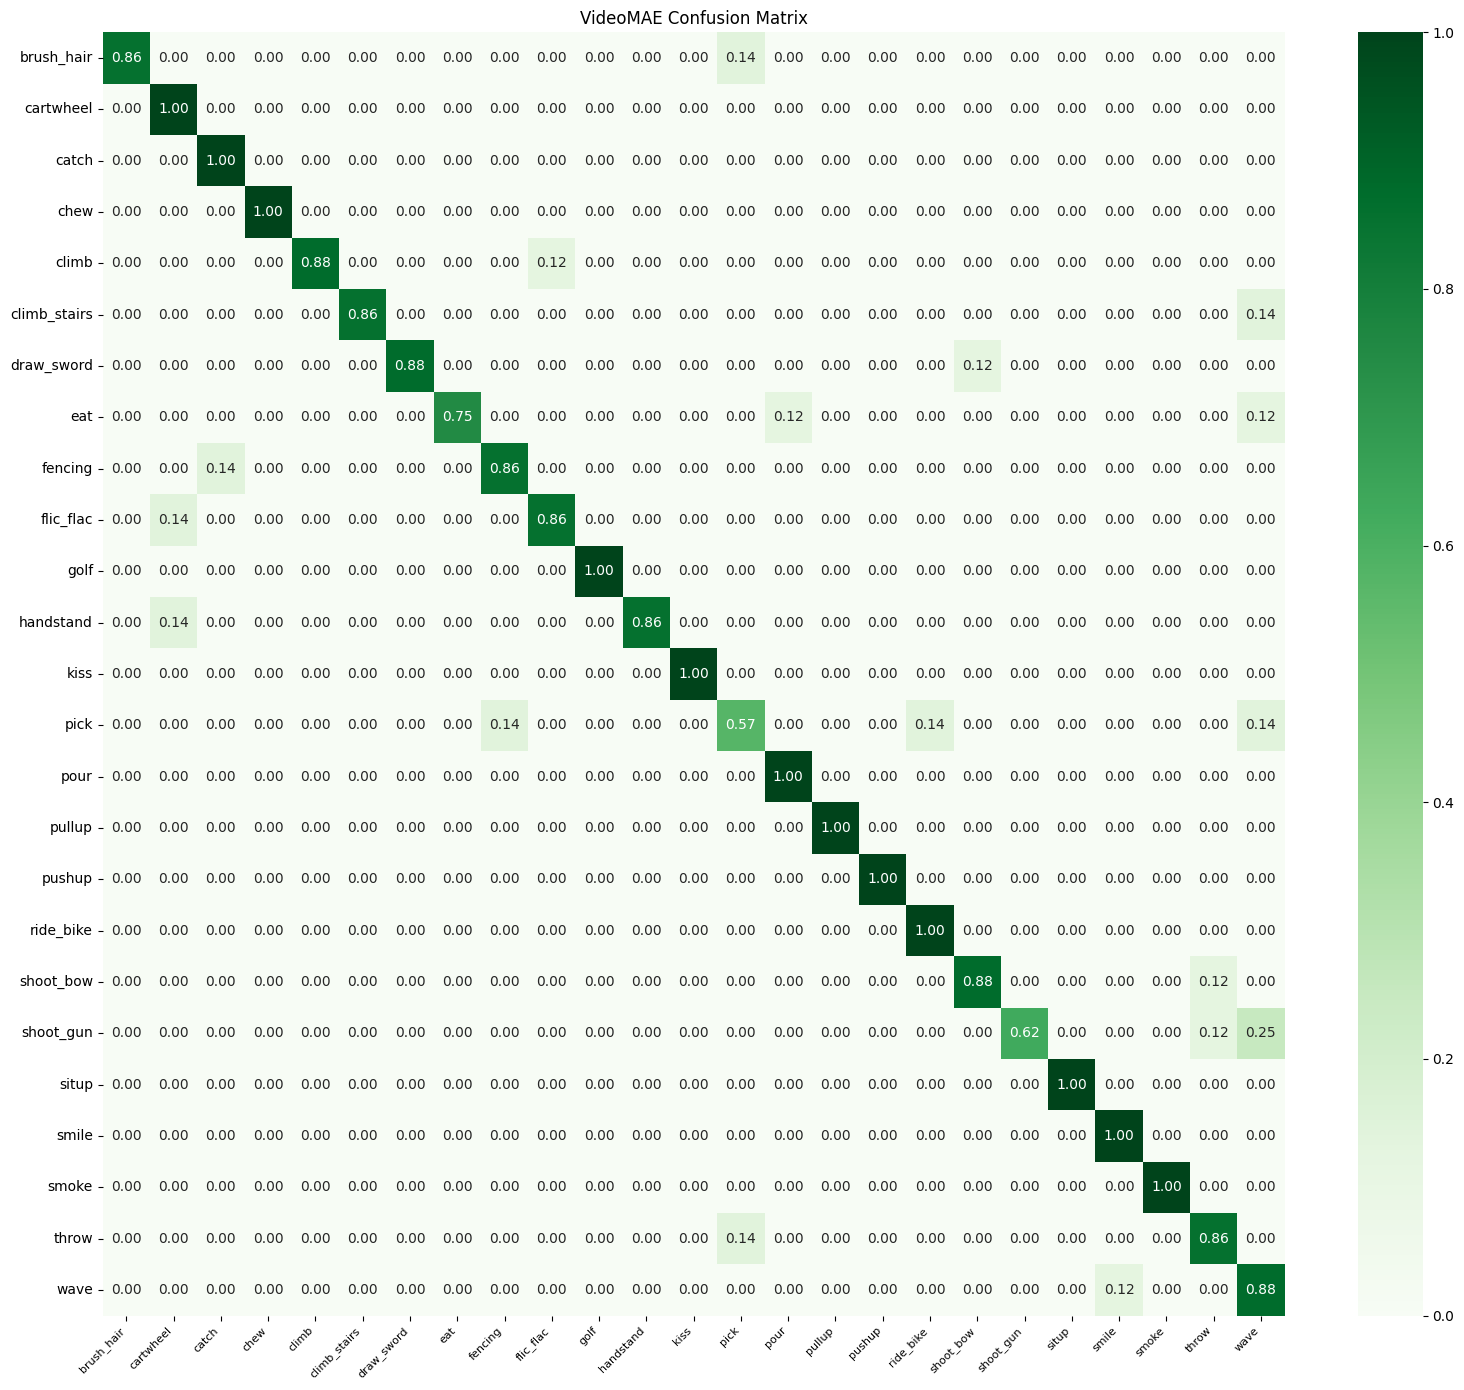


FINAL MODEL COMPARISON
TimeSFormer  Top-1: 88.30%  Top-5: 97.34%
VideoMAE     Top-1: 90.43%  Top-5: 98.40%
Winner: VideoMAE 🏆


In [28]:
# Evaluate VideoMAE on test set
model_vm.eval()
all_preds_vm, all_labels_vm, all_probs_vm = [], [], []

print("Evaluating VideoMAE on test set...")
with torch.no_grad():
    for videos, labels, _ in test_loader_vm:
        videos = videos.to(DEVICE)
        logits = model_vm(videos)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds_vm.extend(preds.tolist())
        all_labels_vm.extend(labels.numpy().tolist())
        all_probs_vm.extend(probs.tolist())

all_preds_vm  = np.array(all_preds_vm)
all_labels_vm = np.array(all_labels_vm)
all_probs_vm  = np.array(all_probs_vm)

# Top-1
top1_vm = (all_preds_vm == all_labels_vm).mean() * 100

# Top-5
top5_correct_vm = sum(
    1 for i, lbl in enumerate(all_labels_vm)
    if lbl in np.argsort(all_probs_vm[i])[-5:]
)
top5_vm = top5_correct_vm / len(all_labels_vm) * 100

print("="*50)
print(f"VideoMAE Top-1: {top1_vm:.2f}%")
print(f"VideoMAE Top-5: {top5_vm:.2f}%")
print("="*50)
print(classification_report(all_labels_vm, all_preds_vm,
      target_names=CLASSES, zero_division=0))

# Confusion matrix
cm_vm = confusion_matrix(all_labels_vm, all_preds_vm)
cm_norm_vm = cm_vm.astype(float) / cm_vm.sum(axis=1, keepdims=True)
plt.figure(figsize=(16, 14))
sns.heatmap(cm_norm_vm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('VideoMAE Confusion Matrix')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/confusion_matrix_videomae.png', dpi=150)
plt.show()

# Final comparison table
print("\n" + "="*50)
print("FINAL MODEL COMPARISON")
print("="*50)
print(f"TimeSFormer  Top-1: 88.30%  Top-5: 97.34%")
print(f"VideoMAE     Top-1: {top1_vm:.2f}%  Top-5: {top5_vm:.2f}%")
print(f"Winner: VideoMAE 🏆")
print("="*50)

In [30]:
# Save everything important
torch.save({
    "timesformer_state": model.state_dict(),
    "videomae_state"   : model_vm.state_dict(),
    "classes"          : CLASSES,
    "results": {
        "timesformer": {"top1": 88.30, "top5": 97.34},
        "videomae"   : {"top1": 90.43, "top5": 98.40},
    }
}, f"{CHECKPOINT_DIR}/all_models_saved.pt")
print("✅ Everything saved! Good night Sree! 😊🌙")

✅ Everything saved! Good night Sree! 😊🌙
